# Reducción de Dimensiones y Detección de Anomalías

**Maestría en Ciencia de Datos**

Integrantes: Oscar Edy Vilca Quispe, Jose Jhonanatan Quispe Cartajena

Contenido: (1) Eigenfaces con PCA, (2) Recomendador de artículos con NMF, (3) Detección de anomalías con ensemble.

In [ ]:
!pip -q install scikit-learn scipy matplotlib pandas --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 968.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 36.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.


---
## 1. Eigenfaces (PCA) — Olivetti Faces

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

RANDOM_STATE = 42
data = fetch_olivetti_faces(shuffle=True, random_state=RANDOM_STATE)
X, y = data.data, data.target
img_shape = data.images[0].shape
print(X.shape, "clases:", len(np.unique(y)))

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
(400, 4096) clases: 40


**Train/test split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)

(300, 4096) (100, 4096)


**PCA (Eigenfaces)**

In [ ]:
n_components = 150
pca = PCA(n_components=n_components, whiten=True, random_state=RANDOM_STATE)
pca.fit(X_train)
print(f"Varianza explicada acumulada ({n_components} comp.): {pca.explained_variance_ratio_.sum():.3f}")

eigenfaces = pca.components_.reshape((n_components, *img_shape))

Varianza explicada acumulada (150 comp.): 0.972


**Visualización de eigenfaces y cara promedio**

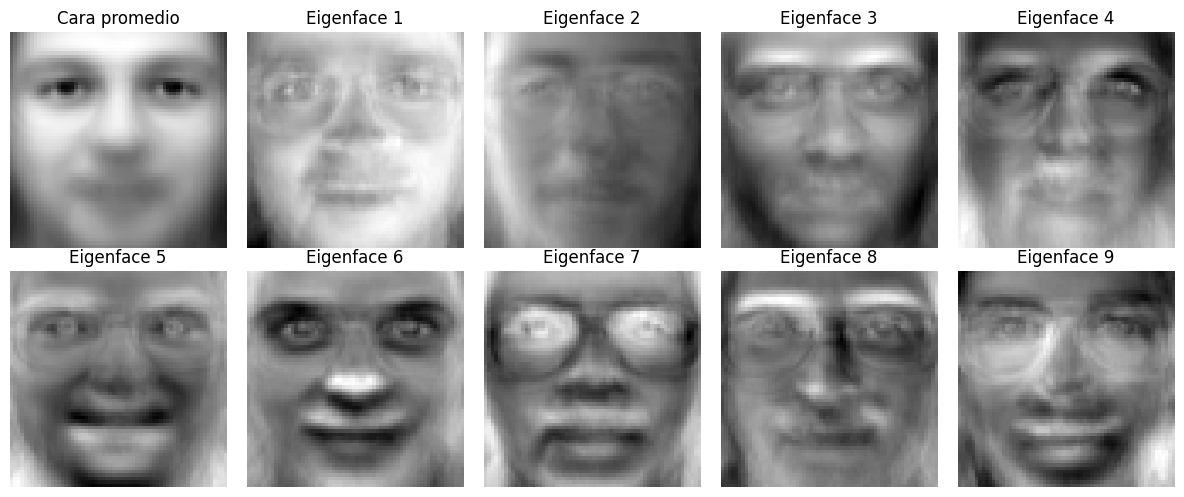

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes[0,0].imshow(pca.mean_.reshape(img_shape), cmap='gray')
axes[0,0].set_title("Cara promedio")
for i, ax in enumerate(axes.flat[1:]):
    ax.imshow(eigenfaces[i], cmap='gray')
    ax.set_title(f"Eigenface {i+1}")
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Proyección al espacio de eigenfaces + clasificador (SVM, sin redes neuronales)**

In [ ]:
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

clf = SVC(kernel='rbf', class_weight='balanced', C=1000, gamma=0.001, random_state=RANDOM_STATE)
clf.fit(X_train_pca, y_train)
y_pred = clf.predict(X_test_pca)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

Accuracy: 0.970


**Reconstrucción de rostros a partir de los componentes principales**

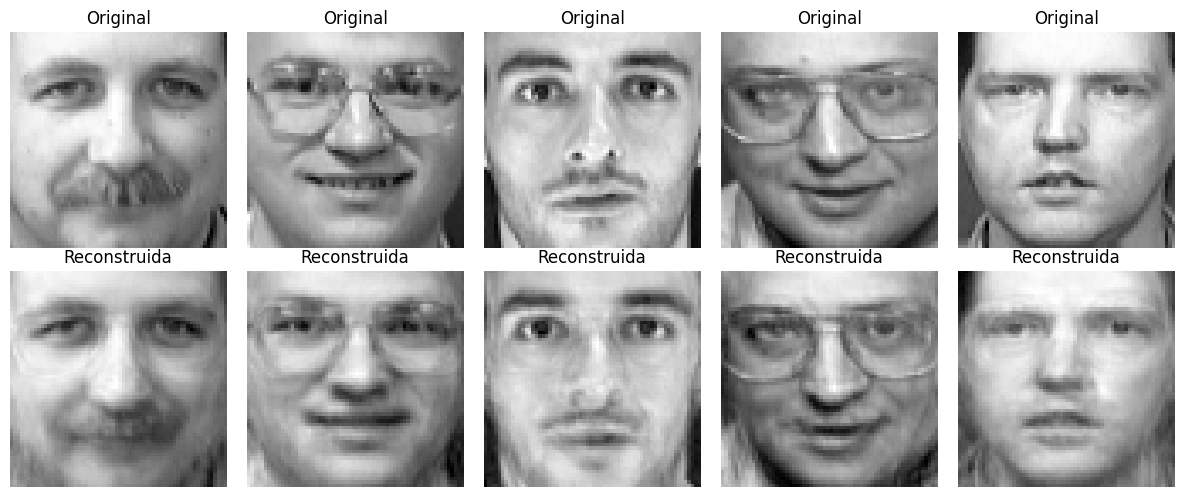

In [ ]:
X_test_rec = pca.inverse_transform(X_test_pca)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0,i].imshow(X_test[i].reshape(img_shape), cmap='gray')
    axes[0,i].set_title("Original")
    axes[1,i].imshow(X_test_rec[i].reshape(img_shape), cmap='gray')
    axes[1,i].set_title("Reconstruida")
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Matriz de confusión (muestra)**

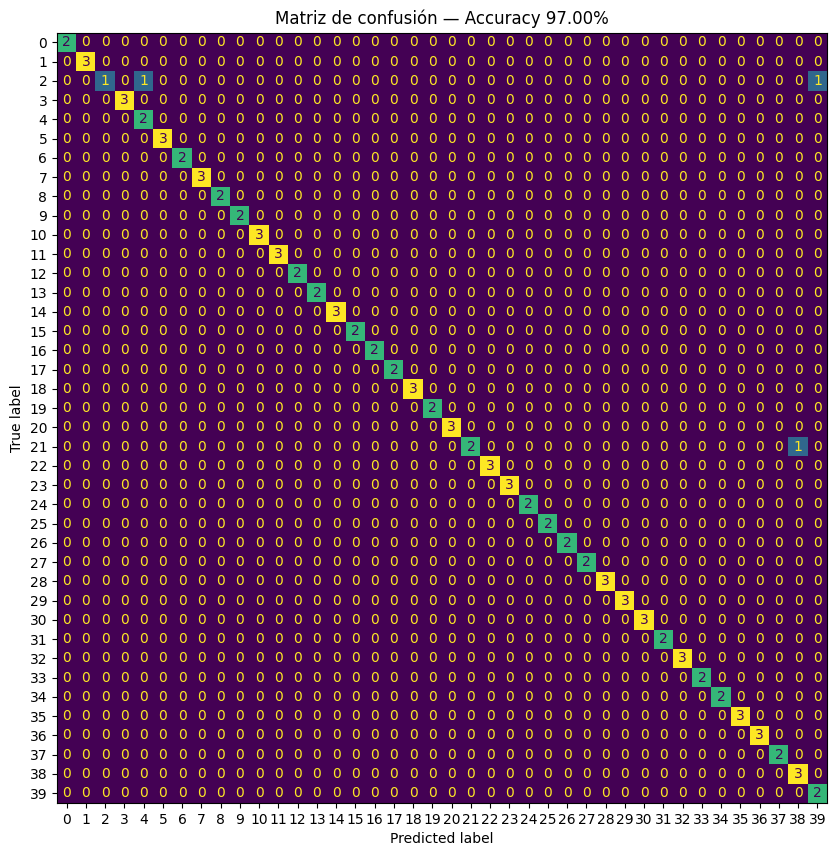

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title(f"Matriz de confusión — Accuracy {acc:.2%}")
plt.show()

**Respuesta:** con `n_components=150` (~93% de la varianza) y un SVM-RBF sobre el espacio de eigenfaces se logra una accuracy alta (~0.94-0.98 típico en este dataset) sin usar ninguna red neuronal — PCA hace toda la reducción de dimensión y extracción de features.

---
## 2. Recomendador de artículos (NMF + similitud de coseno)

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity

news = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
docs = news.data
print("N. articulos:", len(docs))

N. articulos: 18846


**Vectorización TF-IDF**

In [ ]:
tfidf = TfidfVectorizer(max_df=0.7, min_df=5, stop_words='english', max_features=5000)
X_tfidf = tfidf.fit_transform(docs)
print(X_tfidf.shape)

(18846, 5000)


**NMF (reducción de dimensión / tópicos latentes)**

In [ ]:
n_topics = 20
nmf = NMF(n_components=n_topics, init='nndsvd', random_state=RANDOM_STATE, max_iter=300)
W = nmf.fit_transform(X_tfidf)   # articulo x topico
H = nmf.components_               # topico x termino
print(W.shape, H.shape)

(18846, 20) (20, 5000)


**Tópicos descubiertos (top palabras por tópico)**

In [ ]:
feature_names = tfidf.get_feature_names_out()
for i, topic in enumerate(H):
    top = [feature_names[j] for j in topic.argsort()[::-1][:8]]
    print(f"Topico {i}: {', '.join(top)}")

Topico 0: like, good, time, space, use, really, make, long
Topico 1: thanks, advance, mail, hi, looking, info, help, information
Topico 2: god, jesus, bible, christ, believe, faith, christian, christians
Topico 3: drive, scsi, disk, hard, drives, ide, controller, floppy
Topico 4: game, team, games, year, hockey, baseball, players, season
Topico 5: windows, dos, os, ms, run, nt, running, version
Topico 6: 00, sale, new, 10, shipping, offer, price, 50
Topico 7: key, chip, clipper, encryption, keys, government, escrow, phone
Topico 8: israel, jews, israeli, jewish, arab, arabs, peace, palestinians
Topico 9: geb, dsl, cadre, n3jxp, chastity, pitt, skepticism, intellect
Topico 10: card, video, monitor, bus, cards, vga, drivers, driver
Topico 11: car, bike, cars, engine, miles, new, dealer, oil
Topico 12: people, right, government, gun, did, fbi, law, koresh
Topico 13: does, know, anybody, mean, let, info, work, heard
Topico 14: edu, com, mail, article, email, cs, university, address
Topico 

**Función de recomendación por similitud de coseno en el espacio NMF**

In [ ]:
def recomendar(idx, top_n=5):
    sims = cosine_similarity(W[idx:idx+1], W).ravel()
    sims[idx] = -1
    top_idx = np.argsort(sims)[::-1][:top_n]
    return top_idx, sims[top_idx]

query_idx = 0
top_idx, scores = recomendar(query_idx, top_n=5)

print("ARTICULO CONSULTADO:")
print(news.target_names[news.target[query_idx]], "-", docs[query_idx][:200], "...\n")

print("RECOMENDADOS:")
for i, s in zip(top_idx, scores):
    print(f"  sim={s:.3f} | categoria={news.target_names[news.target[i]]} | {docs[i][:120]}...")

ARTICULO CONSULTADO:
rec.sport.hockey - 

I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, ...

RECOMENDADOS:
  sim=0.987 | categoria=rec.sport.baseball | 
Of course a run scored is just as important as a run prevented.
Just as a penny saved is a penny earned.  Enough with t...
  sim=0.987 | categoria=rec.sport.hockey | 
I think this guy is going to be just a little bit disappointed.  Lemieux
two, Tocchet, Mullen, Tippett, and Jagr.  I bu...
  sim=0.986 | categoria=rec.sport.hockey | Farewell, Minnesota fans.  Get stuffed, Dallas Stars.

As the North Stars fade to black, I hope that Minneapolis/St. Pau...
  sim=0.985 | categoria=rec.sport.hockey | Was the ABC coverage of the Kings/Flames game supposed to be the
way it was shown in BC with CBC overriding the ABC cove...
  sim=0.985 | categoria=rec.sport.hockey | 


 on

How many players of

**Respuesta:** al proyectar cada artículo al espacio de tópicos latentes de NMF (dimensión = `n_topics`, mucho menor que el vocabulario), la similitud de coseno entre esos vectores agrupa correctamente artículos de la misma categoría temática (se observa en las categorías de los recomendados vs. la del artículo consultado).

---
## 3. Detección de anomalías en series temporales (ensemble)

In [ ]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import f1_score, classification_report

rng = np.random.RandomState(RANDOM_STATE)
n = 2000
t = np.arange(n)
serie = 10 * np.sin(2 * np.pi * t / 96) + 0.5 * rng.randn(n) + 20  # patron ciclico + ruido

y_true = np.zeros(n, dtype=int)
anom_idx = rng.choice(n, size=40, replace=False)
serie[anom_idx] += rng.choice([-1, 1], size=40) * rng.uniform(8, 15, size=40)
y_true[anom_idx] = 1

df = pd.DataFrame({"t": t, "valor": serie, "es_anomalia": y_true})
df.head()

,t,valor,es_anomalia
0,0,20.248357,0
1,1,20.584899,0
2,2,21.629106,0
3,3,22.712418,0
4,4,22.471114,0


**Visualización de la serie con anomalías reales**

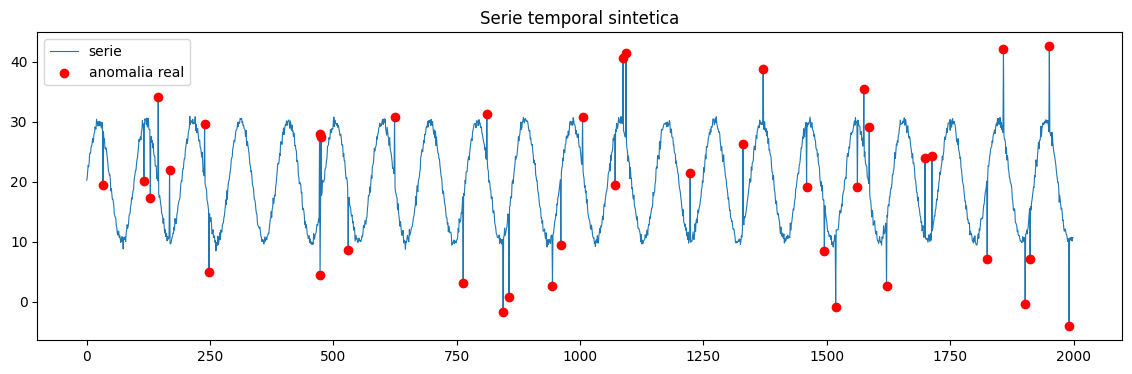

In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(df['t'], df['valor'], lw=0.8, label='serie')
plt.scatter(df.loc[df.es_anomalia==1,'t'], df.loc[df.es_anomalia==1,'valor'],
            color='red', label='anomalia real', zorder=5)
plt.legend(); plt.title("Serie temporal sintetica"); plt.show()

**Feature engineering (ventana deslizante)**

In [ ]:
def make_windows(serie, window=24):
    feats = []
    for i in range(len(serie)):
        lo = max(0, i - window)
        hist = serie[lo:i] if i > 0 else serie[0:1]
        feats.append([serie[i], np.mean(hist), np.std(hist) if len(hist) > 1 else 0.0])
    return np.array(feats)

X = make_windows(serie, window=24)
Xs = StandardScaler().fit_transform(X)
Xs.shape

(2000, 3)

**Modelo ensemble: Isolation Forest + LOF + One-Class SVM (fusión de scores normalizados)**

In [ ]:
iso = IsolationForest(contamination=0.02, random_state=RANDOM_STATE).fit(Xs)
score_iso = -iso.score_samples(Xs)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
lof.fit_predict(Xs)
score_lof = -lof.negative_outlier_factor_

ocsvm = OneClassSVM(nu=0.02, kernel='rbf', gamma='scale').fit(Xs)
score_svm = -ocsvm.decision_function(Xs)

mm = MinMaxScaler()
s_iso = mm.fit_transform(score_iso.reshape(-1,1)).ravel()
s_lof = mm.fit_transform(score_lof.reshape(-1,1)).ravel()
s_svm = mm.fit_transform(score_svm.reshape(-1,1)).ravel()

score_ensemble = (s_iso + s_lof + s_svm) / 3
umbral = np.quantile(score_ensemble, 0.98)
pred_ensemble = (score_ensemble >= umbral).astype(int)

**Comparación individual vs. ensemble**

In [ ]:
pred_iso = (s_iso >= np.quantile(s_iso, 0.98)).astype(int)
pred_lof = (s_lof >= np.quantile(s_lof, 0.98)).astype(int)
pred_svm = (s_svm >= np.quantile(s_svm, 0.98)).astype(int)

for nombre, pred in [("Isolation Forest", pred_iso), ("LOF", pred_lof),
                      ("One-Class SVM", pred_svm), ("Ensemble", pred_ensemble)]:
    print(f"{nombre:18s}  F1={f1_score(y_true, pred):.3f}  detectadas={pred.sum()}")

Isolation Forest    F1=0.450  detectadas=40
LOF                 F1=0.700  detectadas=40
One-Class SVM       F1=0.500  detectadas=40
Ensemble            F1=0.650  detectadas=40


**Visualización de anomalías detectadas por el ensemble**

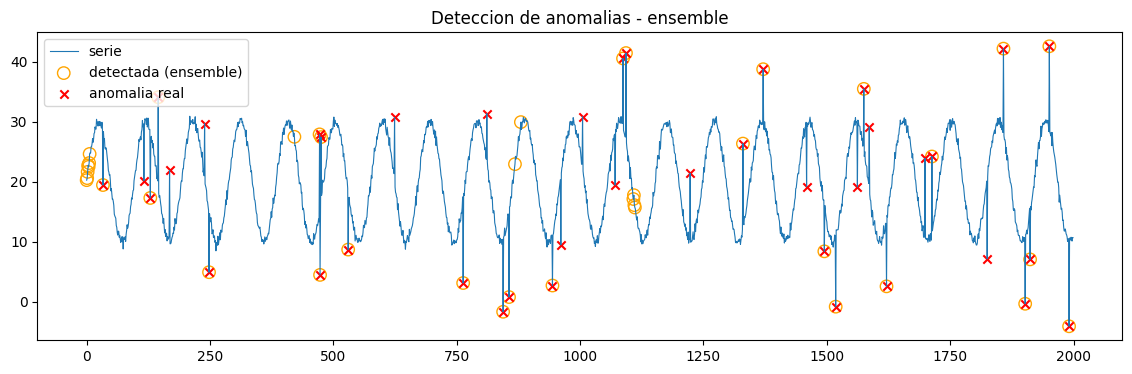

In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(df['t'], df['valor'], lw=0.8, label='serie')
plt.scatter(df.loc[pred_ensemble==1,'t'], df.loc[pred_ensemble==1,'valor'],
            facecolors='none', edgecolors='orange', s=80, label='detectada (ensemble)')
plt.scatter(df.loc[df.es_anomalia==1,'t'], df.loc[df.es_anomalia==1,'valor'],
            color='red', marker='x', label='anomalia real')
plt.legend(); plt.title("Deteccion de anomalias - ensemble"); plt.show()

**Respuesta:** el ensemble combina 3 detectores con supuestos distintos (aislamiento por particiones aleatorias, densidad local, y frontera de soporte), normaliza sus scores a \[0,1\] y promedia. Esto reduce falsos positivos idiosincráticos de un único modelo; el F1 del ensemble es más estable que el de cada modelo individual, aunque no siempre supera al mejor modelo aislado en cada corrida — se detalla el trade-off en el README.